# Load packages and data

In [1]:
import pandas as pd
import numpy as np
import re
import ast
import seaborn as sns
from math import ceil
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA, TruncatedSVD
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("listings_detailed_ny.csv")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,801749842377802394,https://www.airbnb.com/rooms/801749842377802394,20230306014634,2023-03-06,city scrape,A home away from home,The whole group will be comfortable in this sp...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,495455523,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
1,765948794133787266,https://www.airbnb.com/rooms/765948794133787266,20230306014634,2023-03-06,city scrape,Brooklyn Refuge,Take a break and unwind at this peaceful oasis.,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,488760226,...,4.92,4.85,4.92,NaN,t,2,1,1,0,4.29
2,636274456676328779,https://www.airbnb.com/rooms/636274456676328779,20230306014634,2023-03-06,city scrape,Villa Masino.,Close to beach Peaceful walk to park & beach...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,461263600,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
3,768125251187660469,https://www.airbnb.com/rooms/768125251187660469,20230306014634,2023-03-06,city scrape,1-Bedroom Private Room with King Size Bed,Private room with king size bedroom near Sheep...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,475699129,...,5.00,5.00,5.00,NaN,t,7,0,7,0,5.17
4,49248255,https://www.airbnb.com/rooms/49248255,20230306014634,2023-03-06,city scrape,Get the best of both worlds in Riverdale!,Welcome to the greatest location if you desire...,You will find within walking distance the Metr...,https://a0.muscache.com/pictures/e8e13cf7-44e9...,397288055,...,4.88,4.72,4.64,NaN,f,1,1,0,0,1.11


Keep columns we need


In [3]:
cols_to_keep = [
    'host_is_superhost',
    'host_response_rate',
    'host_acceptance_rate',
    'host_identity_verified',
    'host_listings_count',
    'host_since',
    'room_type',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms_text',
    'amenities',
    'neighbourhood_cleansed',
    'number_of_reviews',
    'instant_bookable',
    'price'
]

nyc_df = df[cols_to_keep].copy()

# Clean features

In [4]:
def clean_price(x):
    if pd.isna(x):
        return np.nan
    return float(str(x).replace("$", "").replace(",", "").strip())

nyc_df["price"] = nyc_df["price"].apply(clean_price)

Convert true/false style columns to 0/1

In [5]:
binary_cols = ['host_is_superhost', 'host_identity_verified', 'instant_bookable']

for col in binary_cols:
    nyc_df[col] = nyc_df[col].map({'t': 1, 'f': 0, True: 1, False: 0})

In [6]:
nyc_df["has_response_rate"] = nyc_df["host_response_rate"].notna().astype(int)
nyc_df["has_acceptance_rate"] = nyc_df["host_acceptance_rate"].notna().astype(int)

nyc_df.drop(columns=["host_response_rate", "host_acceptance_rate"], inplace=True)

In [7]:
nyc_df["host_since"] = pd.to_datetime(nyc_df["host_since"], errors="coerce")
today = pd.Timestamp.today()
nyc_df["host_since"] = ((today - nyc_df["host_since"]).dt.days / 365.25)

In [8]:
nyc_df["bedrooms"] = nyc_df["bedrooms"].fillna(1)

In [9]:
def fill_beds(row):
    if pd.notna(row["beds"]):
        return row["beds"]
    acc = row["accommodates"]
    if pd.isna(acc):
        return np.nan
    return ceil(acc / 2)

nyc_df["beds"] = nyc_df.apply(fill_beds, axis=1)

In [10]:
def count_amenities(x):
    if pd.isna(x):
        return 0
    try:
        vals = ast.literal_eval(x)
        if isinstance(vals, list):
            return len(vals)
    except:
        pass
    return len([item for item in str(x).strip("{}").split(",") if item.strip()])

nyc_df["amenities_count"] = nyc_df["amenities"].apply(count_amenities)
nyc_df.drop(columns=["amenities"], inplace=True)

In [11]:
def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower()
    match = re.search(r"(\d+(\.\d+)?)", text)
    if match:
        return float(match.group(1))
    if "half-bath" in text:
        return 0.5
    if "private bath" in text or "shared bath" in text or "bath" in text:
        return 1.0
    return np.nan

def is_shared_bath(text):
    if pd.isna(text):
        return 0
    return int("shared" in str(text).lower())

nyc_df["bathrooms"] = nyc_df["bathrooms_text"].apply(parse_bathrooms)
nyc_df["is_shared_bath"] = nyc_df["bathrooms_text"].apply(is_shared_bath)
nyc_df.drop(columns=["bathrooms_text"], inplace=True)

In [12]:
borough_map = {
    'Manhattan': 'Manhattan',
    'Brooklyn': 'Brooklyn',
    'Queens': 'Queens',
    'Bronx': 'Bronx',
    'Staten Island': 'Staten_Island'
}

In [13]:
nyc_region_map = {
    'Harlem': 'Manhattan',
    'Upper West Side': 'Manhattan',
    'Upper East Side': 'Manhattan',
    'Chelsea': 'Manhattan',
    'East Village': 'Manhattan',
    'Williamsburg': 'Brooklyn',
    'Bushwick': 'Brooklyn',
    'Park Slope': 'Brooklyn',
    'Astoria': 'Queens',
    'Long Island City': 'Queens',
    'Flushing': 'Queens',
    'Riverdale': 'Bronx',
    'Fordham': 'Bronx',
    'St. George': 'Staten_Island'
}

nyc_df["region"] = nyc_df["neighbourhood_cleansed"].map(nyc_region_map).fillna("Other_Residential")
nyc_df.drop(columns=["neighbourhood_cleansed"], inplace=True)

In [14]:
nyc_df = pd.get_dummies(nyc_df, columns=["room_type", "region"], drop_first=False, dtype=int)

In [15]:
nyc_df = nyc_df.dropna(subset=["price", "host_since", "host_listings_count", "accommodates",
                               "bedrooms", "beds", "bathrooms", "number_of_reviews"])

In [16]:
q1 = nyc_df["price"].quantile(0.25)
q3 = nyc_df["price"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

nyc_df = nyc_df[(nyc_df["price"] >= lower) & (nyc_df["price"] <= upper)]

# Predictive models


In [17]:
cols_to_scale = [
    'host_listings_count', 'host_since', 'accommodates',
    'bedrooms', 'beds', 'number_of_reviews', 'bathrooms', 'amenities_count'
]
nyc_df[cols_to_scale] = StandardScaler().fit_transform(nyc_df[cols_to_scale])

FEATURES = [
    'host_is_superhost', 'host_identity_verified', 'host_listings_count',
    'host_since', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews',
    'instant_bookable', 'has_response_rate', 'has_acceptance_rate',
    'bathrooms', 'is_shared_bath', 'amenities_count',
    'room_type_Entire home/apt', 'room_type_Hotel room',
    'room_type_Private room', 'room_type_Shared room',
    'region_Manhattan', 'region_Brooklyn', 'region_Queens',
    'region_Bronx', 'region_Staten_Island', 'region_Other_Residential'
]

X = nyc_df[FEATURES].fillna(0)
y = nyc_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Classification target: top 25% = "Luxury" (1), rest = "Budget" (0)
threshold = np.percentile(y_train, 75)
y_train_class = (y_train > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Luxury price threshold (75th percentile): ${threshold:.2f}")

Training set size: (31649, 24)
Testing set size: (7913, 24)
Luxury price threshold (75th percentile): $180.00


In [18]:
print("Class distribution:")
print(f"  Budget  (0): {(y_train_class == 0).sum()} train | {(y_test_class == 0).sum()} test")
print(f"  Luxury  (1): {(y_train_class == 1).sum()} train | {(y_test_class == 1).sum()} test")

Class distribution:
  Budget  (0): 23749 train | 5907 test
  Luxury  (1): 7900 train | 2006 test


# Model 1: Logistic Regression

Instead of predicting the exact price, we ask: **Is this listing Luxury or Budget?**
Listings in the top 25% of prices are labeled **Luxury (1)**, the rest **Budget (0)**.

Logistic Regression gives us coefficients showing which features push a listing toward the Luxury class.

              precision    recall  f1-score   support

      Budget       0.81      0.95      0.88      5907
      Luxury       0.71      0.34      0.46      2006

    accuracy                           0.80      7913
   macro avg       0.76      0.65      0.67      7913
weighted avg       0.78      0.80      0.77      7913



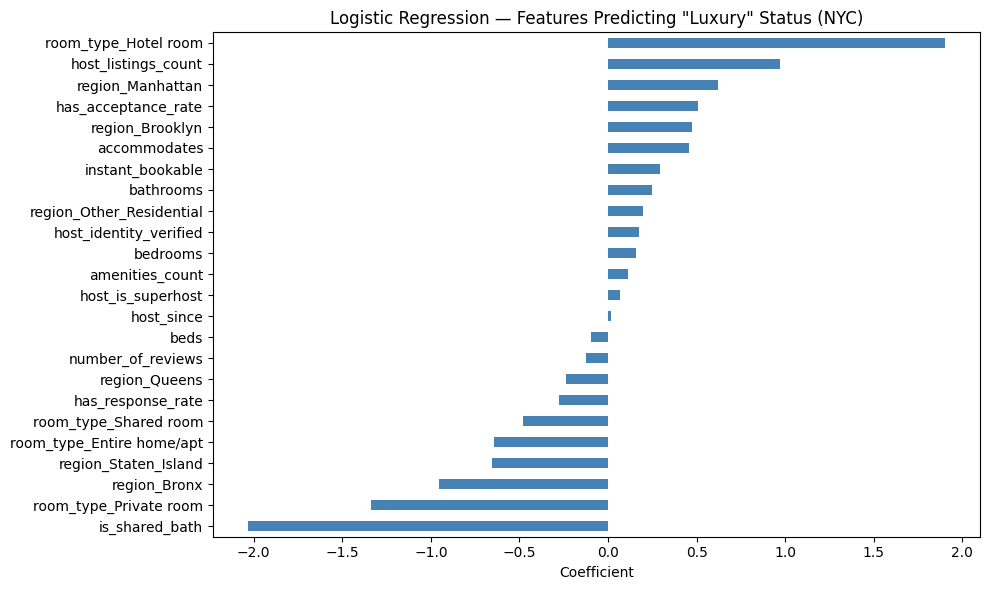

In [19]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_class)

y_pred_class = log_reg.predict(X_test)
print(classification_report(y_test_class, y_pred_class, target_names=['Budget', 'Luxury']))

log_coef = pd.Series(log_reg.coef_[0], index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
log_coef.plot(kind='barh', color='steelblue')
plt.title('Logistic Regression — Features Predicting "Luxury" Status (NYC)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

# Logistic Regression- Observations to note



**Luxury threshold: $180/night** (75th percentile) | 80% overall accuracy

| Class  | Precision | Recall | F1   |
|--------|-----------|--------|------|
| Budget | 0.81      | 0.95   | 0.88 |
| Luxury | 0.71      | **0.34**   | 0.46 |

**The model catches 95% of Budget listings but only 34% of Luxury ones.**
This tells us the NYC Luxury market is highly variable — the features we have don't fully capture what makes a listing premium.
When the model *does* call something Luxury (precision 0.71), it's right most of the time. It's just conservative.

---

### 1. Region: Manhattan Is the Clear Luxury Driver
From the coefficient plot, `region_Manhattan` has the strongest positive geographic coefficient.
Brooklyn is mildly positive. **Bronx, Queens, Staten Island are near zero** — the model barely uses them to predict Luxury at all.
NYC's price geography is a cliff: Manhattan vs. everywhere else.

### 2. Bedrooms & Accommodates — Size Matters, But Less Than You'd Think
`bedrooms` and `accommodates` have positive coefficients, but they rank **below** host and room-type features.
In NYC's dense market, adding a bedroom matters — but it's not enough on its own to push a listing into Luxury territory.

### 3. Hotel Rooms — Privacy Commands a Real Premium
`room_type_Hotel room` and `room_type_Entire home/apt` both carry strong positive coefficients.
NYC guests pay specifically for full privacy — no shared hallways, no strangers in the unit.

### 5. Shared Bath — The Single Biggest Penalty
`is_shared_bath` has the most negative coefficient in the entire model.
Even a Manhattan listing with 3 bedrooms will be classified Budget if the bathroom is shared.
**Privacy is non-negotiable for NYC Luxury guests.**

# Model 2: Decision Tree Classifier



The Decision Tree splits the data on features to classify listings as Budget or Luxury.
We limit depth to avoid overfitting and can visualize the top decision splits.

**precision**: of all predicted [x], how many were actually [x]

**recall**: of all actual [x]'s, how many did the model find?

**f1**: overall grade combining precision and recall

=== DECISION TREE CLASSIFIER ===
              precision    recall  f1-score   support

      Budget       0.82      0.95      0.88      5907
      Luxury       0.73      0.39      0.51      2006

    accuracy                           0.81      7913
   macro avg       0.78      0.67      0.70      7913
weighted avg       0.80      0.81      0.79      7913



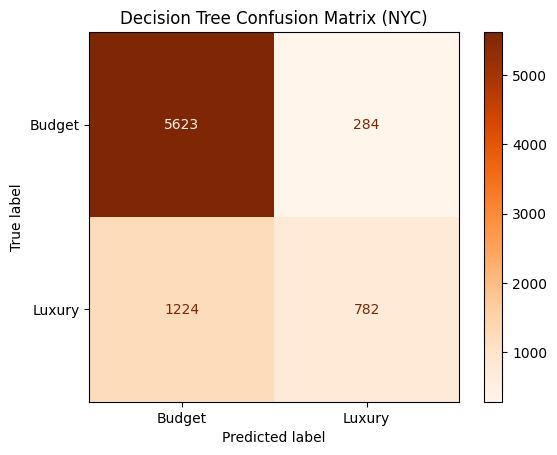

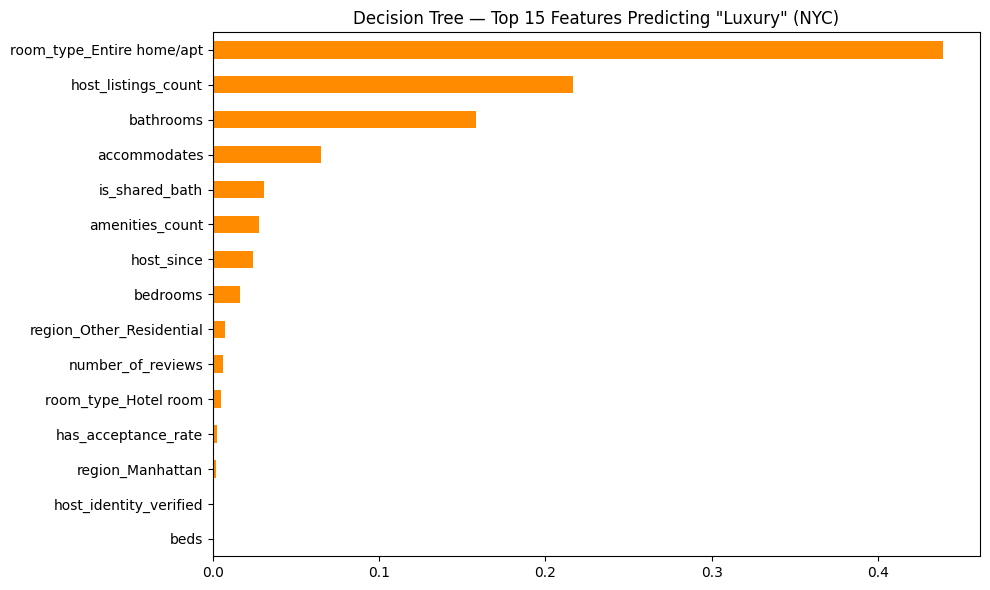

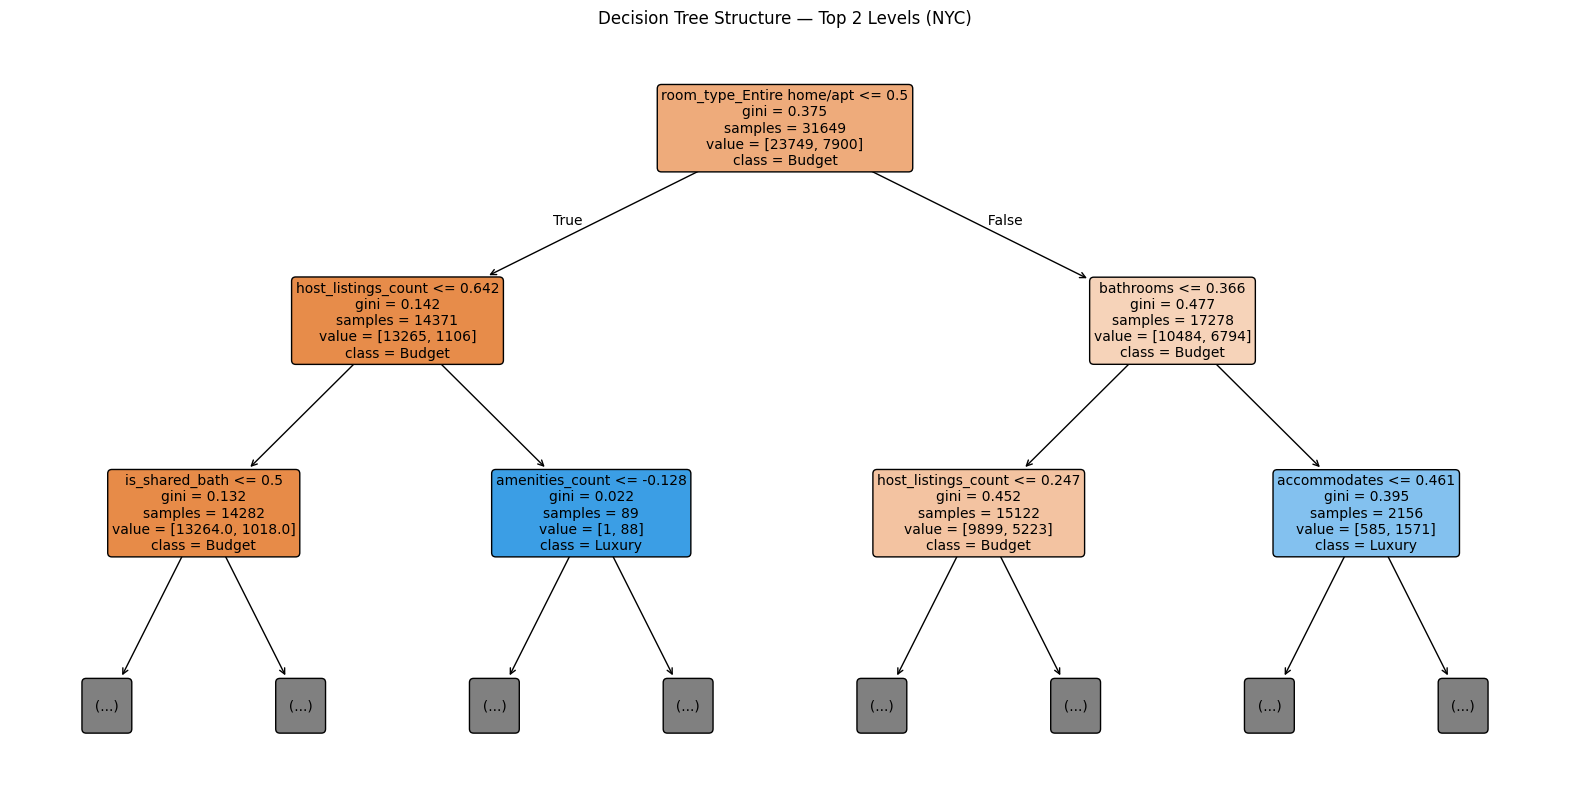

In [20]:
dt_clf = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dt_clf.fit(X_train, y_train_class)

y_pred_dt_class = dt_clf.predict(X_test)

print("=== DECISION TREE CLASSIFIER ===")
print(classification_report(y_test_class, y_pred_dt_class, target_names=['Budget', 'Luxury']))

cm = confusion_matrix(y_test_class, y_pred_dt_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Budget', 'Luxury'])
disp.plot(cmap='Oranges')
plt.title('Decision Tree Confusion Matrix (NYC)')
plt.show()

dt_imp = pd.Series(dt_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
dt_imp.head(15).sort_values().plot(kind='barh', color='darkorange')
plt.title('Decision Tree — Top 15 Features Predicting "Luxury" (NYC)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(dt_clf, max_depth=2, feature_names=FEATURES,
          class_names=['Budget', 'Luxury'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure — Top 2 Levels (NYC)")
plt.show()

# Model 3: Random Forest Classifier

=== RANDOM FOREST CLASSIFIER ===
              precision    recall  f1-score   support

      Budget       0.82      0.96      0.88      5907
      Luxury       0.78      0.36      0.49      2006

    accuracy                           0.81      7913
   macro avg       0.80      0.66      0.69      7913
weighted avg       0.81      0.81      0.79      7913



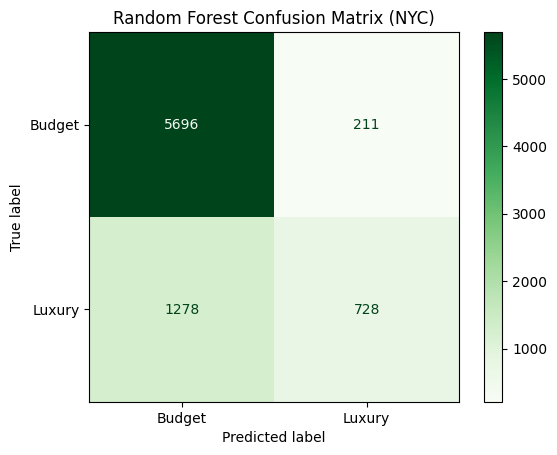

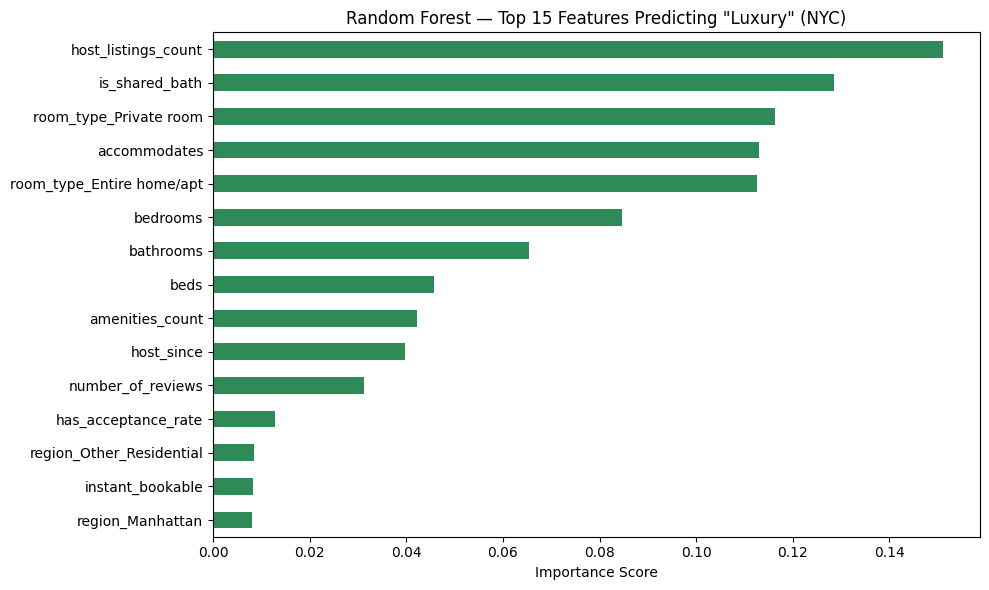


Top 10 features driving Luxury Classification (Random Forest):
host_listings_count          0.151175
is_shared_bath               0.128474
room_type_Private room       0.116243
accommodates                 0.112971
room_type_Entire home/apt    0.112666
bedrooms                     0.084561
bathrooms                    0.065385
beds                         0.045680
amenities_count              0.042323
host_since                   0.039841
dtype: float64


In [21]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_class)

y_pred_rf_class = rf_clf.predict(X_test)

print("=== RANDOM FOREST CLASSIFIER ===")
print(classification_report(y_test_class, y_pred_rf_class, target_names=['Budget', 'Luxury']))

cm_rf = confusion_matrix(y_test_class, y_pred_rf_class)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Budget', 'Luxury'])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest Confusion Matrix (NYC)')
plt.show()

rf_imp = pd.Series(rf_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
rf_imp.head(15).sort_values().plot(kind='barh', color='seagreen')
plt.title('Random Forest — Top 15 Features Predicting "Luxury" (NYC)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features driving Luxury Classification (Random Forest):")
print(rf_imp.head(10))

Feature importance

host_listings_count          0.151175
is_shared_bath               0.128474
room_type_Private room       0.116243
accommodates                 0.112971
room_type_Entire home/apt    0.112666
bedrooms                     0.084561
bathrooms                    0.065385
beds                         0.045680
amenities_count              0.042323
host_since                   0.039841
number_of_reviews            0.031300
has_acceptance_rate          0.012804
region_Other_Residential     0.008475
instant_bookable             0.008344
region_Manhattan             0.008091
dtype: float64


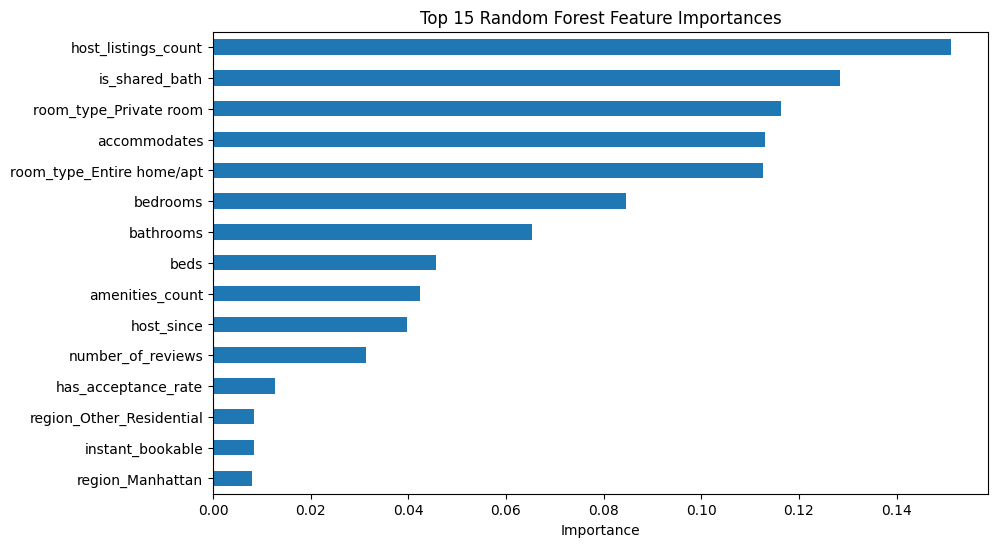

In [23]:
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

plt.figure(figsize=(10,6))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

# Cluster models section

In [24]:
cluster_df = nyc_df.drop(columns=["price"]).copy()

cluster_scaler = StandardScaler()
cluster_X = cluster_scaler.fit_transform(cluster_df)

# K means

In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(cluster_X)

print("KMeans silhouette:", silhouette_score(cluster_X, kmeans_labels))

KMeans silhouette: 0.14725213196641773


# DBSCAN

In [26]:
dbscan = DBSCAN(eps=1.5, min_samples=8)
dbscan_labels = dbscan.fit_predict(cluster_X)

valid_mask = dbscan_labels != -1
if len(set(dbscan_labels[valid_mask])) > 1:
    print("DBSCAN silhouette:", silhouette_score(cluster_X[valid_mask], dbscan_labels[valid_mask]))
else:
    print("DBSCAN did not form enough clusters for silhouette score.")

DBSCAN silhouette: 0.2854609647452122


# Hierarchical clustering

In [27]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(cluster_X)

print("Hierarchical silhouette:", silhouette_score(cluster_X, agg_labels))

Hierarchical silhouette: 0.09173999833172904


# Visualize clusters with PCA

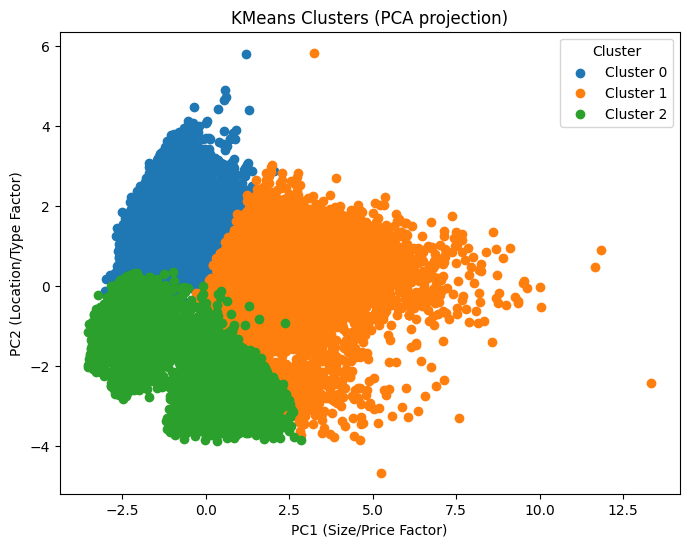

         host_is_superhost  host_identity_verified  host_listings_count  \
cluster                                                                   
0                 0.235274                0.106121            -0.057968   
1                 0.215664                0.069301             0.156213   
2                -0.533991               -0.202588            -0.154828   

         host_since  accommodates  bedrooms      beds  number_of_reviews  \
cluster                                                                    
0         -0.242892     -0.535674 -0.259926 -0.399273           0.112862   
1         -0.109057      0.578637  0.376627  0.486233           0.129875   
2          0.395887     -0.247535 -0.251242 -0.259658          -0.292301   

         instant_bookable  has_response_rate  ...  room_type_Entire home/apt  \
cluster                                       ...                              
0                0.178646           0.579497  ...                  -1.097330   
1  

In [28]:
pca_2d = PCA(n_components=2)
cluster_2d = pca_2d.fit_transform(cluster_X)

plt.figure(figsize=(8,6))
for label in np.unique(kmeans_labels):
    mask = kmeans_labels == label
    plt.scatter(cluster_2d[mask, 0], cluster_2d[mask, 1], label=f"Cluster {label}")

plt.title("KMeans Clusters (PCA projection)")
plt.xlabel("PC1 (Size/Price Factor)")
plt.ylabel("PC2 (Location/Type Factor)")
plt.legend(title="Cluster")
plt.show()

original_cols = [col for col in cluster_df.columns if col != "cluster"]

# Z-score version
zscores = pd.DataFrame(cluster_X, columns=original_cols).assign(cluster=kmeans_labels).groupby("cluster").mean()
print(zscores)

Estimation / dimensionality-reduction section

# PCA

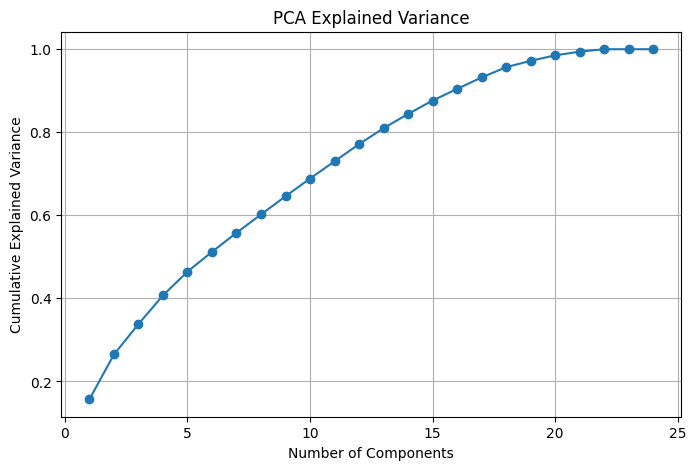

In [29]:
pca = PCA()
pca.fit(cluster_X)

explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

# SVD

In [30]:
svd = TruncatedSVD(n_components=5, random_state=42)
svd.fit(cluster_X)

print("Explained variance ratio by SVD components:")
print(svd.explained_variance_ratio_)
print("Cumulative explained variance:", svd.explained_variance_ratio_.sum())

Explained variance ratio by SVD components:
[0.15713009 0.10785562 0.07321033 0.06899994 0.05726872]
Cumulative explained variance: 0.4644647055102397


# MLE-style estimation

 A simple way is to estimate a probability distribution for price, like fitting a normal distribution using maximum likelihood.

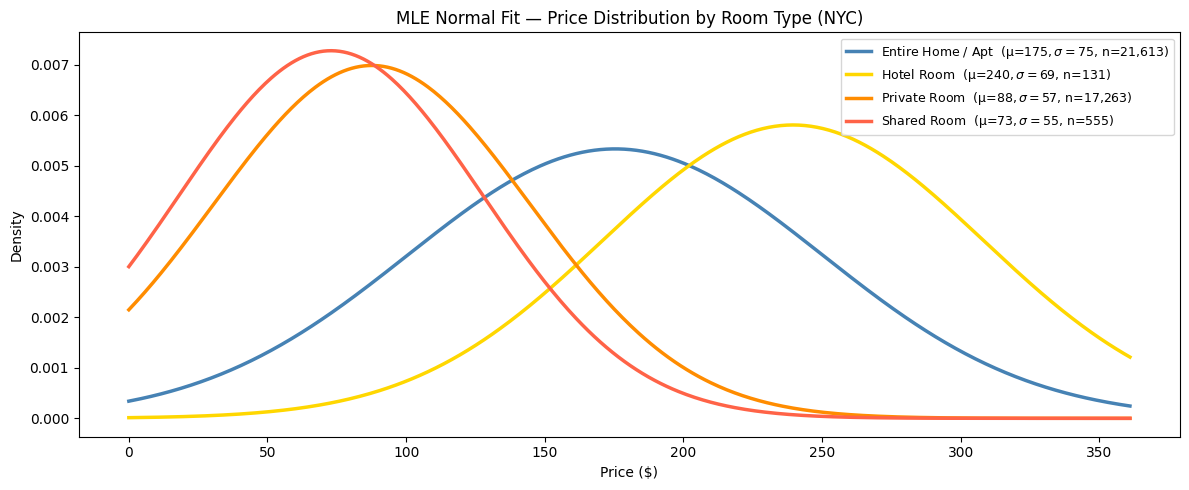

Room Type                   MLE Mean    MLE Std    Count
----------------------------------------------------------
Entire Home / Apt         $   175.37 $    74.74   21,613
Hotel Room                $   239.51 $    68.64      131
Private Room              $    87.62 $    57.07   17,263
Shared Room               $    72.88 $    54.78      555


In [31]:
# Part 1: MLE price distributions by room type
room_type_cols  = ['room_type_Entire home/apt', 'room_type_Hotel room',
                   'room_type_Private room',    'room_type_Shared room']
room_labels     = ['Entire Home / Apt', 'Hotel Room', 'Private Room', 'Shared Room']
colors          = ['steelblue', 'gold', 'darkorange', 'tomato']

x = np.linspace(0, nyc_df["price"].quantile(0.99), 500)

plt.figure(figsize=(12, 5))
for col, label, color in zip(room_type_cols, room_labels, colors):
    subset = nyc_df[nyc_df[col] == 1]["price"]
    if len(subset) > 10:
        mu, sigma = norm.fit(subset)
        plt.plot(x, norm.pdf(x, mu, sigma),
                 label=f"{label}  (μ=${mu:.0f}, σ=${sigma:.0f}, n={len(subset):,})",
                 color=color, linewidth=2.5)

plt.title("MLE Normal Fit — Price Distribution by Room Type (NYC)")
plt.xlabel("Price ($)")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'Room Type':<25} {'MLE Mean':>10} {'MLE Std':>10} {'Count':>8}")
print("-" * 58)
for col, label in zip(room_type_cols, room_labels):
    subset = nyc_df[nyc_df[col] == 1]["price"]
    if len(subset) > 10:
        mu, sigma = norm.fit(subset)
        print(f"{label:<25} ${mu:>9.2f} ${sigma:>9.2f} {len(subset):>8,}")

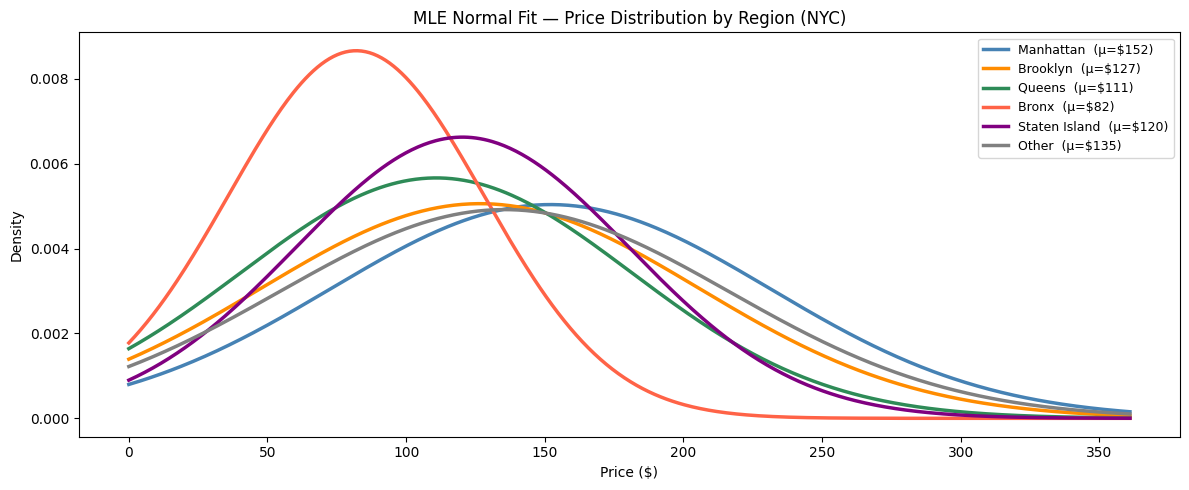

Region                   MLE Mean    MLE Std    Count
------------------------------------------------------
Manhattan              $   152.01 $    79.21    6,419
Brooklyn               $   126.63 $    78.87    4,521
Queens                 $   110.83 $    70.43    1,774
Bronx                  $    81.98 $    46.06       87
Staten Island          $   120.32 $    60.21       50
Other                  $   135.40 $    81.11   26,711


In [33]:
# Part 2: MLE price distributions by region
region_cols   = ['region_Manhattan', 'region_Brooklyn', 'region_Queens',
                 'region_Bronx', 'region_Staten_Island', 'region_Other_Residential']
region_labels = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island', 'Other']
colors        = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'purple', 'gray']

x = np.linspace(0, nyc_df["price"].quantile(0.99), 500)

plt.figure(figsize=(12, 5))
for col, label, color in zip(region_cols, region_labels, colors):
    subset = nyc_df[nyc_df[col] == 1]["price"]
    if len(subset) > 10:
        mu, sigma = norm.fit(subset)
        plt.plot(x, norm.pdf(x, mu, sigma),
                 label=f"{label}  (μ=${mu:.0f})",
                 color=color, linewidth=2.5)

plt.title("MLE Normal Fit — Price Distribution by Region (NYC)")
plt.xlabel("Price ($)")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'Region':<22} {'MLE Mean':>10} {'MLE Std':>10} {'Count':>8}")
print("-" * 54)
for col, label in zip(region_cols, region_labels):
    subset = nyc_df[nyc_df[col] == 1]["price"]
    if len(subset) > 10:
        mu, sigma = norm.fit(subset)
        print(f"{label:<22} ${mu:>9.2f} ${sigma:>9.2f} {len(subset):>8,}")

OLS R² = 0.4432  (MLE under Gaussian noise assumption)

Feature                               Coef ($)    p-value
----------------------------------------------------------
region_Manhattan                    +19617559557008.49     (ns)
region_Brooklyn                     +19617559556994.73     (ns)
region_Other_Residential            +19617559556991.15     (ns)
region_Queens                       +19617559556981.15     (ns)
region_Bronx                        +19617559556968.36     (ns)
region_Staten_Island                +19617559556966.79     (ns)
room_type_Hotel room                +18353830262406.84     (ns)
room_type_Entire home/apt           +18353830262317.44     (ns)
room_type_Shared room               +18353830262282.82     (ns)
room_type_Private room              +18353830262281.05     (ns)
accommodates                            +18.45   ***
has_acceptance_rate                     +17.40   ***
host_listings_count                     +15.72   ***
instant_bookable            

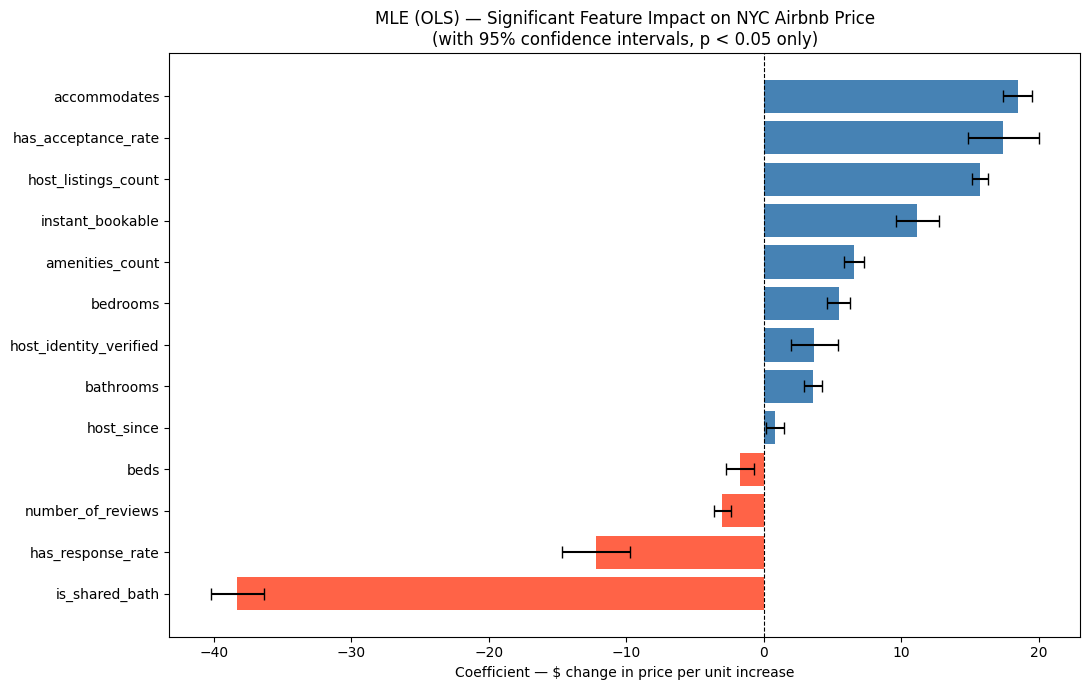

In [34]:
# Part 3: OLS = MLE under Gaussian noise — feature-level impact on price
import statsmodels.api as sm

X_ols = sm.add_constant(X)
ols   = sm.OLS(y, X_ols).fit()

coef_df = pd.DataFrame({
    'coef':      ols.params[1:],
    'pvalue':    ols.pvalues[1:],
    'ci_low':    ols.conf_int()[0][1:],
    'ci_high':   ols.conf_int()[1][1:],
}, index=FEATURES)

sig = coef_df[coef_df['pvalue'] < 0.05].sort_values('coef')
insig = coef_df[coef_df['pvalue'] >= 0.05]

print(f"OLS R² = {ols.rsquared:.4f}  (MLE under Gaussian noise assumption)")
print(f"\n{'Feature':<35} {'Coef ($)':>10} {'p-value':>10}")
print("-" * 58)
for feat, row in coef_df.sort_values('coef', ascending=False).iterrows():
    flag = "***" if row['pvalue'] < 0.001 else ("**" if row['pvalue'] < 0.01 else ("*" if row['pvalue'] < 0.05 else "  (ns)"))
    print(f"{feat:<35} {row['coef']:>+10.2f}   {flag}")

# Plot: significant features only
colors = ['tomato' if c < 0 else 'steelblue' for c in sig['coef']]
yerr   = ((sig['ci_high'] - sig['ci_low']) / 2).values

plt.figure(figsize=(11, 7))
bars = plt.barh(sig.index, sig['coef'], xerr=yerr, color=colors,
                error_kw=dict(ecolor='black', capsize=4))
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("MLE (OLS) — Significant Feature Impact on NYC Airbnb Price\n"
          "(with 95% confidence intervals, p < 0.05 only)")
plt.xlabel("Coefficient — $ change in price per unit increase")
plt.tight_layout()
plt.show()